# K-Means Clustering

K-means is an **unsupervised machine learning** algorithm that automatically groups similar data points into clusters — without needing any labels.

**We will use a realistic customer dataset throughout this tutorial.**

### What we will cover
1. What clustering is and when to use it  
2. How the K-means algorithm works  
3. Scaling data before clustering  
4. Fitting K-means  
5. Finding the right number of clusters — the Elbow Method  
6. Measuring cluster quality — the Silhouette Score  
7. Interpreting and visualising the final segments

## Step 1 - Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries imported.")

Libraries imported.


## Step 2 - Load the Dataset

We will work with a **retail customer dataset**. Each row represents one customer with two features:

- `annual_income` — how much the customer earns per year (£)
- `spending_score` — how much they spend in store (0–100 scale)

The goal is to segment customers into meaningful groups so the marketing team can target each group appropriately.

In [4]:
# Create a realistic customer dataset
# Five natural customer types are baked into the data:
#   1. Low income, low spenders
#   2. Low income, high spenders
#   3. Mid income, mid spenders
#   4. High income, low spenders
#   5. High income, high spenders

def make_customer_data(n=200):
    rng = np.random.default_rng(42)
    segments = [
        (20000, 15, 0.20),   # low income, low spend
        (22000, 82, 0.15),   # low income, high spend
        (55000, 50, 0.30),   # mid income, mid spend
        (85000, 18, 0.18),   # high income, low spend
        (90000, 85, 0.17),   # high income, high spend
    ]
    rows = []
    for income_mean, score_mean, frac in segments:
        size = int(n * frac)
        incomes = rng.normal(income_mean, 4000, size).clip(10000, 120000)
        scores  = rng.normal(score_mean, 6, size).clip(1, 100)
        rows.append(np.column_stack([incomes, scores]))
    data = np.vstack(rows)
    return pd.DataFrame(data, columns=['annual_income', 'spending_score'])

df = make_customer_data(n=200)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 2)


,annual_income,spending_score
0,21218.868319,19.459525
1,15840.063575,18.258926
2,23001.804783,11.006942
3,23762.258866,16.392968
4,12195.859245,15.700115


**Explaining the function above**

```
a) n = 200 - we want a sample of 200 customers
b) rng = np.random.default_rng(42) - a random number generator with seed 42. The seed fixes the randomness so you get the same data every time you run it. 
default_rng is the modern numpy way to do this.

c) segments = [
        (20000, 15, 0.20),
        (22000, 82, 0.15),
        ...
    ]
A list of tuples, one per customer type. Each tuple holds three values: (income_mean, score_mean, fraction). For example (20000, 15, 0.20) means: average income £20,000, average spending score 15, and this group makes up 20% of the dataset.

d) rows = []
An empty list that will collect the generated data for each segment before combining them.

e) for income_mean, score_mean, frac in segments:
Loops through each segment, unpacking its three values into named variables on each iteration.

f) size = int(n * frac)
Calculates how many customers to generate for this segment. For n=200 and frac=0.20, that gives int(200 × 0.20) = 40 customers.

g)  incomes = rng.normal(income_mean, 4000, size).clip(10000, 120000)
Generates size random income values drawn from a normal distribution centred on income_mean with a standard deviation of £4,000 — so most values fall within ±£4,000 of the mean. .clip(10000, 120000) ensures no value falls below £10,000 or above £120,000.


h) scores = rng.normal(score_mean, 6, size).clip(1, 100)
Same idea for spending scores — centred on score_mean with std of 6. Clipped to the valid range 1–100.

i) rows.append(np.column_stack([incomes, scores]))
np.column_stack combines the two 1D arrays (incomes, scores) side by side into a 2D array with shape (size, 2). That block is added to the rows list.

j) data = np.vstack(rows)
Stacks all five segment blocks vertically into one big array of shape (200, 2) — all customers together.

k) return pd.DataFrame(data, columns=['annual_income', 'spending_score'])
Wraps the numpy array in a pandas DataFrame with proper column names, so it's easy to work with.

```

In [25]:
# Basic statistics
df.describe().round(1)

,annual_income,spending_score
count,200.0,200.0
mean,54250.3,48.2
std,28406.6,28.5
min,12195.9,4.9
25%,22380.2,19.4
50%,54481.1,47.4
75%,85152.8,78.2
max,96464.8,99.5


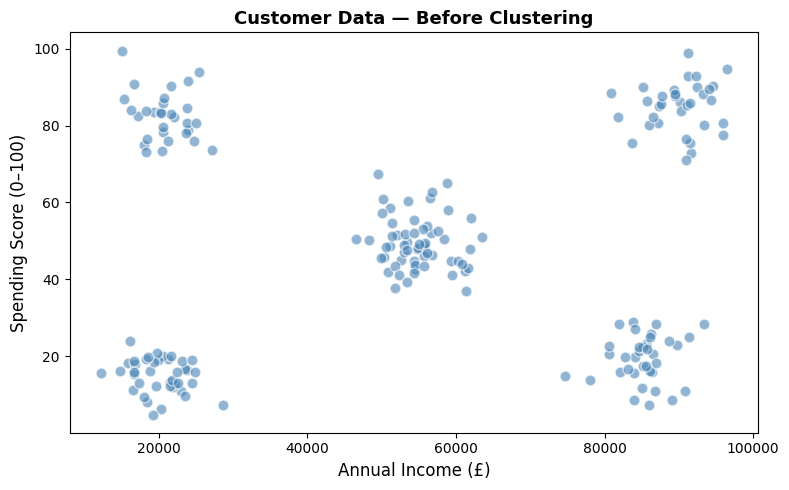

Can you already spot any natural groups?


In [5]:
# Plot the raw unlabelled data
plt.figure(figsize=(8, 5))
plt.scatter(df['annual_income'], df['spending_score'],
            color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Annual Income (£)', fontsize=12)
plt.ylabel('Spending Score (0–100)', fontsize=12)
plt.title('Customer Data — Before Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Can you already spot any natural groups?")

## Step 3 - Why We Must Scale the Data

K-means groups points by **distance**. If one feature uses large numbers (e.g. income in the tens of thousands) and another uses small numbers (e.g. score 0–100), the large-number feature will dominate the distance calculation and the clustering will be skewed.

**StandardScaler** fixes this by converting every feature to a common scale:
- Mean = 0  
- Standard deviation = 1

Always scale before clustering.

In [6]:
# Scale the features
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df[['annual_income', 'spending_score']])

print("Before scaling:")
print(f"  annual_income  — mean: {df['annual_income'].mean():10.2f},  std: {df['annual_income'].std():8.1f}")
print(f"  spending_score — mean: {df['spending_score'].mean():10.1f},  std: {df['spending_score'].std():8.1f}")

print("\nAfter scaling:")
print(f"  feature 1 — mean: {X_scaled[:,0].mean():6.3f},  std: {X_scaled[:,0].std():.3f}")
print(f"  feature 2 — mean: {X_scaled[:,1].mean():6.3f},  std: {X_scaled[:,1].std():.3f}")

Before scaling:
  annual_income  — mean:   54250.33,  std:  28406.6
  spending_score — mean:       48.2,  std:     28.5

After scaling:
  feature 1 — mean: -0.000,  std: 1.000
  feature 2 — mean: -0.000,  std: 1.000


## Step 4 - How K-Means Works

K-means repeats two steps until the centroids stop moving:

```
1. INITIALISE  — place k centroids randomly in the data space
2. ASSIGN      — assign each point to its nearest centroid
3. UPDATE      — move each centroid to the mean of its assigned points
4. REPEAT steps 2–3 until nothing changes
```

**Centroid** — the centre of a cluster (the average position of all points in it).

**Inertia (WCSS — Within-Cluster Sum of Squares)** — the total squared distance from every point to its centroid. K-means tries to minimise this value:

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Lower WCSS = more compact, tighter clusters.

**`init='k-means++'`** - instead of placing centroids at random, this smarter method spreads them out across the data first, which avoids bad starting positions and usually converges faster.

## Step 5 - Finding the Right Number of Clusters: The Elbow Method

Before fitting the final model we need to choose **k** - the number of clusters.

The **Elbow Method** works by:
1. Fitting K-means for k = 1, 2, 3, … 10
2. Recording the WCSS (inertia) for each k
3. Plotting WCSS vs k and looking for the **`elbow`** — the point where the curve bends sharply

Adding more clusters always reduces WCSS, but at some point the improvement becomes small. The elbow is where that diminishing return begins — and that's our best choice for k.

In [7]:
# Calculate WCSS for k = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k  →  WCSS")
for k, w in zip(k_range, wcss):
    print(f"k={k:2d}  →  {w:.2f}")

k  →  WCSS
k= 1  →  400.00
k= 2  →  244.23
k= 3  →  148.00
k= 4  →  62.34
k= 5  →  11.96
k= 6  →  9.90
k= 7  →  8.76
k= 8  →  7.63
k= 9  →  6.72
k=10  →  6.01


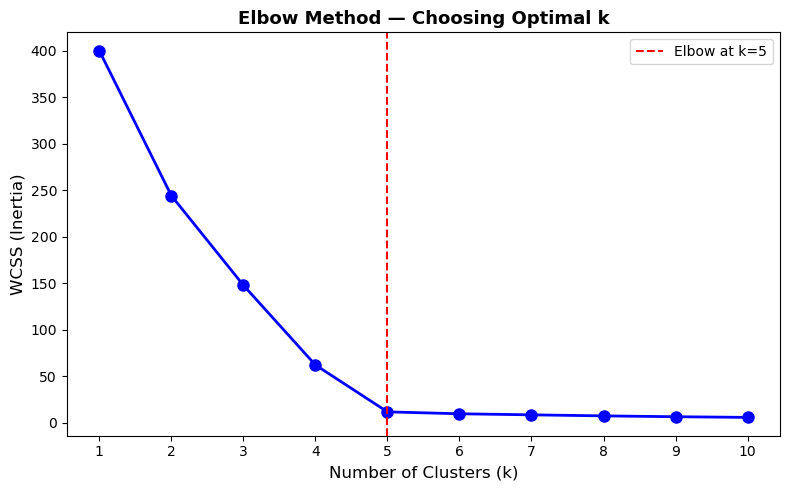

In [29]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Elbow at k=5')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method — Choosing Optimal k', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 - Confirming with the Silhouette Score

The **Silhouette Score** gives a second opinion on the best k. It measures how well each point fits inside its own cluster compared to neighbouring clusters.

- **Score close to +1** — the point sits deep inside its cluster and far from others. Excellent.
- **Score near 0** — the point is close to the boundary between two clusters.
- **Score below 0** — the point may have been assigned to the wrong cluster.

We calculate the average silhouette score across all points for each value of k. **The highest score indicates the best k.**

> Note: Silhouette score requires at least 2 clusters, so we start from k=2.

In [30]:
# Calculate silhouette score for k = 2 to 10
sil_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k:2d}  →  silhouette score: {score:.4f}")

best_k = k_range_sil[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k}")

k= 2  →  silhouette score: 0.4389
k= 3  →  silhouette score: 0.5427
k= 4  →  silhouette score: 0.6843
k= 5  →  silhouette score: 0.8055
k= 6  →  silhouette score: 0.6877
k= 7  →  silhouette score: 0.6265
k= 8  →  silhouette score: 0.5635
k= 9  →  silhouette score: 0.5224
k=10  →  silhouette score: 0.4211

Best k by silhouette score: 5


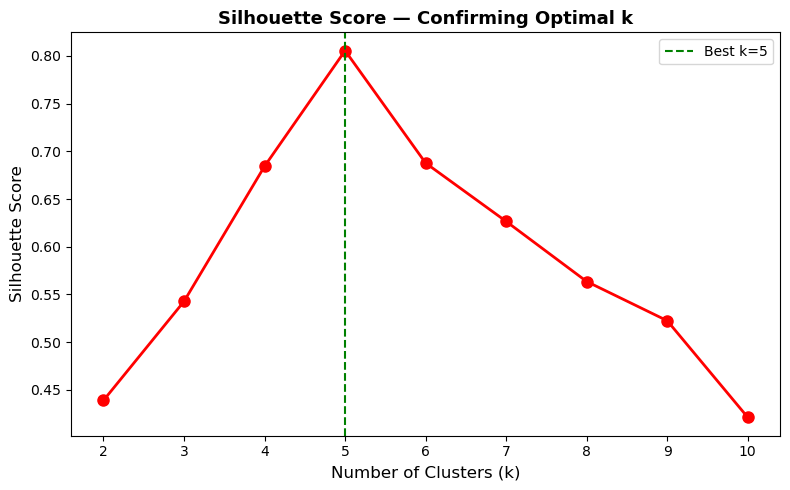

In [12]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), sil_scores, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=1.5,
            label=f'Best k={best_k}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score — Confirming Optimal k', fontsize=13, fontweight='bold')
plt.xticks(list(k_range_sil))
plt.legend()
plt.tight_layout()
plt.show()

Both methods agree: **k = 5** is the best choice. This matches the five natural customer types visible in the raw scatter plot.

## Step 7- Fit the Final Model

Now we fit K-means with k = 5 and assign every customer to a segment.

In [31]:
# Fit the final model with optimal k
kmeans_final = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['segment'] = kmeans_final.fit_predict(X_scaled) # training 

print(f"Inertia (WCSS): {kmeans_final.inertia_:.2f}")
print(f"\nCustomers per segment:")
print(df['segment'].value_counts().sort_index())

Inertia (WCSS): 11.96

Customers per segment:
segment
0    60
1    34
2    40
3    36
4    30
Name: count, dtype: int64


## Step 8 - Visualise the Clusters

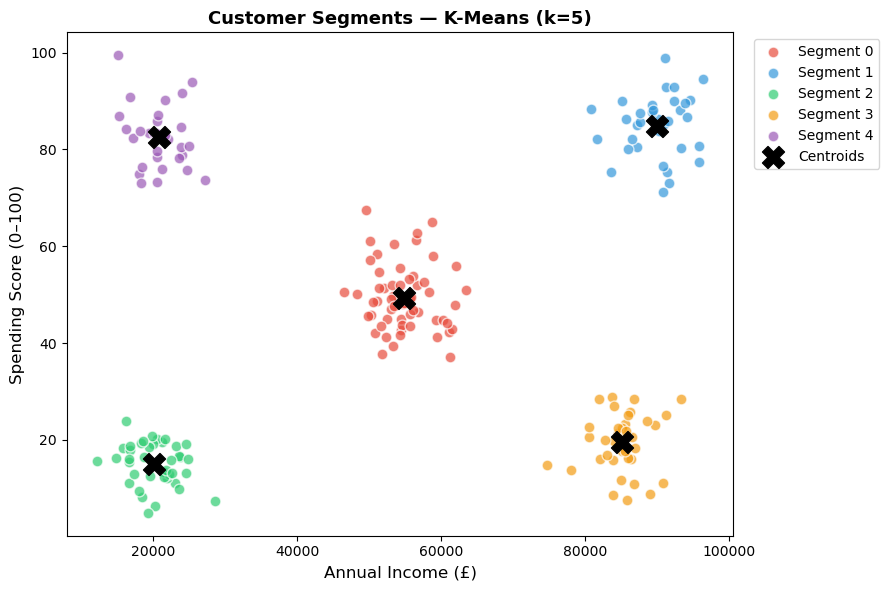

In [32]:
# Scatter plot coloured by segment
# Transform centroids back to original scale for plotting
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

colours = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(9, 6))
for seg in range(5):
    mask = df['segment'] == seg
    plt.scatter(df.loc[mask, 'annual_income'],
                df.loc[mask, 'spending_score'],
                c=colours[seg], label=f'Segment {seg}',
                alpha=0.7, edgecolors='white', s=60)

# Plot centroids
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=250, zorder=5, label='Centroids')

plt.xlabel('Annual Income (£)', fontsize=12)
plt.ylabel('Spending Score (0–100)', fontsize=12)
plt.title('Customer Segments — K-Means (k=5)', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 9 - Interpret the Segments

Numbers alone don't tell the full story. We need to understand what each cluster *means* in business terms.

In [21]:
# Summarise each segment
summary = df.groupby('segment')[['annual_income', 'spending_score']].mean().round(0)
summary.columns = ['Avg Income (£)', 'Avg Spending Score']
summary['Count'] = df.groupby('segment')['segment'].count()
print(summary)

         Avg Income (£)  Avg Spending Score  Count
segment                                           
0               54887.0                49.0     60
1               90028.0                85.0     34
2               20153.0                15.0     40
3               85172.0                19.0     36
4               20787.0                83.0     30


In [33]:
# Label each segment with a meaningful business name
# (Based on low/high income vs low/high spending score)
segment_labels = {
    seg: name for seg, name in zip(
        summary.sort_values(['Avg Income (£)', 'Avg Spending Score']).index,
        [
            'Low Income, Low Spend',
            'Low Income, High Spend',
            'Average Customers',
            'High Income, Low Spend',
            'High Income, High Spend'
        ]
    )
}

summary['Business Label'] = summary.index.map(segment_labels)
print(summary)

         Avg Income (£)  Avg Spending Score  Count           Business Label
segment                                                                    
0               54887.0                49.0     60        Average Customers
1               90028.0                85.0     34  High Income, High Spend
2               20153.0                15.0     40    Low Income, Low Spend
3               85172.0                19.0     36   High Income, Low Spend
4               20787.0                83.0     30   Low Income, High Spend


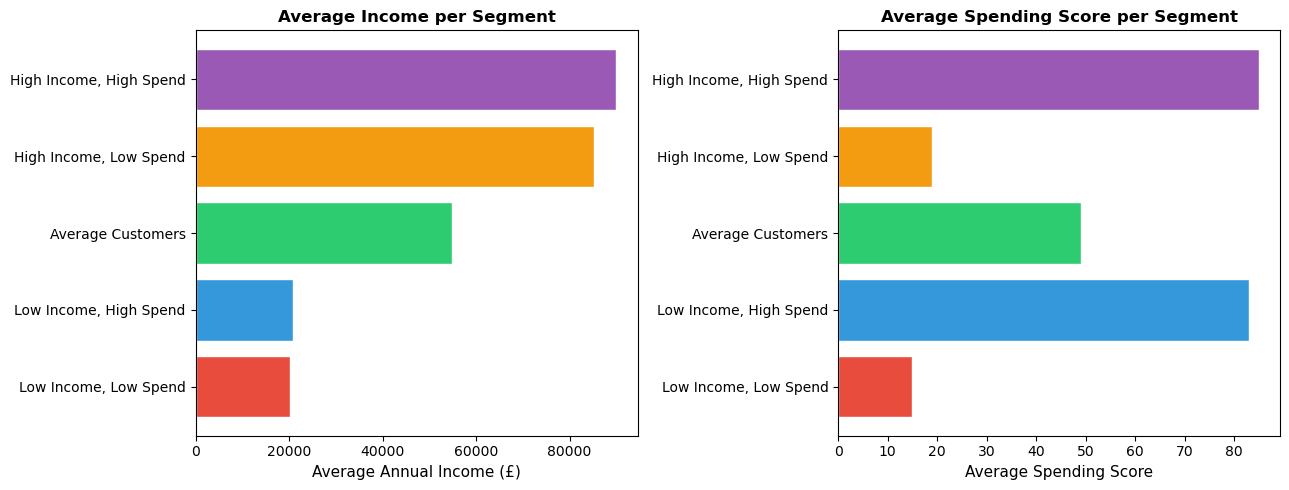

In [40]:
# Bar charts: average income and spending score per segment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_order = summary.sort_values('Avg Income (£)').index

axes[0].barh([segment_labels[s] for s in seg_order],
             summary.loc[seg_order, 'Avg Income (£)'],
             color=colours, edgecolor='white')
axes[0].set_xlabel('Average Annual Income (£)', fontsize=11)
axes[0].set_title('Average Income per Segment', fontsize=12, fontweight='bold')

axes[1].barh([segment_labels[s] for s in seg_order],
             summary.loc[seg_order, 'Avg Spending Score'],
             color=colours, edgecolor='white')
axes[1].set_xlabel('Average Spending Score', fontsize=11)
axes[1].set_title('Average Spending Score per Segment', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 10 - Summary and Key Takeaways

K-means workflow:

```
1. Load data              — understand the features and their scale
2. Scale features         — StandardScaler so no feature dominates distances
3. Elbow method           — plot WCSS vs k to spot the elbow
4. Silhouette score       — confirm the best k independently
5. Fit final model        — KMeans(n_clusters=k, init='k-means++', n_init=10)
6. Visualise              — scatter plot coloured by cluster
7. Interpret              — give each cluster a meaningful business name
```

### Key parameters to remember

| Parameter | What it does |
|-----------|-------------|
| `n_clusters` | Number of clusters k |
| `init='k-means++'` | Smarter centroid initialisation — avoids bad random starts |
| `n_init=10` | Runs 10 times, keeps the best result |
| `random_state` | Fixes randomness so results are reproducible |

### When NOT to use K-means
- Clusters are not roughly spherical (e.g. ring-shaped or crescent-shaped data)
- You don't know how many clusters to expect
- Data contains many outliers (they pull centroids toward them)
- Features are categorical rather than numeric